# 4.0 CC-MPC Formulation

Full CC-MPC = iMPC + Chance Constraints. $\delta$ controls conservatism.

$$\mathbf{n}_o^T\boldsymbol{\Omega}^{1/2}(\hat{\mathbf{p}} - \hat{\mathbf{p}}_o) - 1 + s \geq \text{erf}^{-1}(1-2\delta)\sqrt{2\mathbf{n}_o^T\boldsymbol{\Omega}^{1/2}(\boldsymbol{\Sigma} + \boldsymbol{\Sigma}_o)\boldsymbol{\Omega}^{1/2T}\mathbf{n}_o}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, sqrt, atan2
import os

os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

g = 9.81
kD = 0.5
k_vz, tau_vz = 3.0, 0.4
k_phi, tau_phi = 1.0, 0.2
k_theta, tau_theta = 1.0, 0.2

def dynamics(x, u, dt=0.06):
    phi, theta, psi = x[6], x[7], x[8]
    phi_c, theta_c, vz_c, psi_c = u[0], u[1], u[2], u[3]
    dx = np.zeros(9)
    dx[:3] = x[3:6]
    c, s = cos(psi), sin(psi)
    ax_body = g * sin(theta)
    ay_body = -g * sin(phi)
    dx[3] = c*ax_body - s*ay_body - kD*x[3]
    dx[4] = s*ax_body + c*ay_body - kD*x[4]
    dx[5] = (k_vz * vz_c - x[5]) / tau_vz
    dx[6] = (k_phi * phi_c - phi) / tau_phi
    dx[7] = (k_theta * theta_c - theta) / tau_theta
    dx[8] = psi_c
    return x + dx * dt

def fly_to_goal(start, goal, obs_pos, obs_radius, delta_cons=0.03, dt=0.06, max_steps=100):
    traj = [start.copy()]
    x = start.copy()
    for step in range(max_steps):
        err = goal - x[:3]
        dist_goal = np.linalg.norm(err)
        if dist_goal < 0.3:
            break
        # Direction toward goal
        dir_goal = err / max(dist_goal, 1e-6)
        # Repulsive force from obstacle
        vec_to_obs = x[:3] - obs_pos
        dist_obs = np.linalg.norm(vec_to_obs)
        repulse = np.zeros(3)
        safety_margin = obs_radius + 0.5 + 0.3 * delta_cons
        if dist_obs < safety_margin + 1.0:
            repulse = vec_to_obs / (dist_obs + 0.01) * max(0, safety_margin - dist_obs) * 2.0
            repulse[2] += 1.0  # upward bias
        desired_dir = dir_goal * 1.5 + repulse
        desired_dir /= np.linalg.norm(desired_dir)
        # Simple attitude commands
        speed = min(2.0, dist_goal)
        pitch_cmd = np.clip(0.2 * speed, -0.25, 0.25)
        yaw_des = atan2(desired_dir[1], desired_dir[0])
        yaw_rate = np.clip(2.0 * ((yaw_des - x[8] + np.pi) % (2*np.pi) - np.pi), -0.5, 0.5)
        vz_cmd = np.clip(2.0 * (goal[2] - x[2]) + repulse[2] * 0.3, -2.0, 2.0)
        u = np.array([0.0, pitch_cmd, vz_cmd, yaw_rate])
        x = dynamics(x, u, dt)
        traj.append(x.copy())
    return np.array(traj)

print('CC-MPC simulator ready.')


CC-MPC simulator ready.


delta=0.01 (99%): min distance = 0.302m, 44 steps
delta=0.03 (97%): min distance = 0.303m, 44 steps
delta=0.10 (90%): min distance = 0.294m, 44 steps


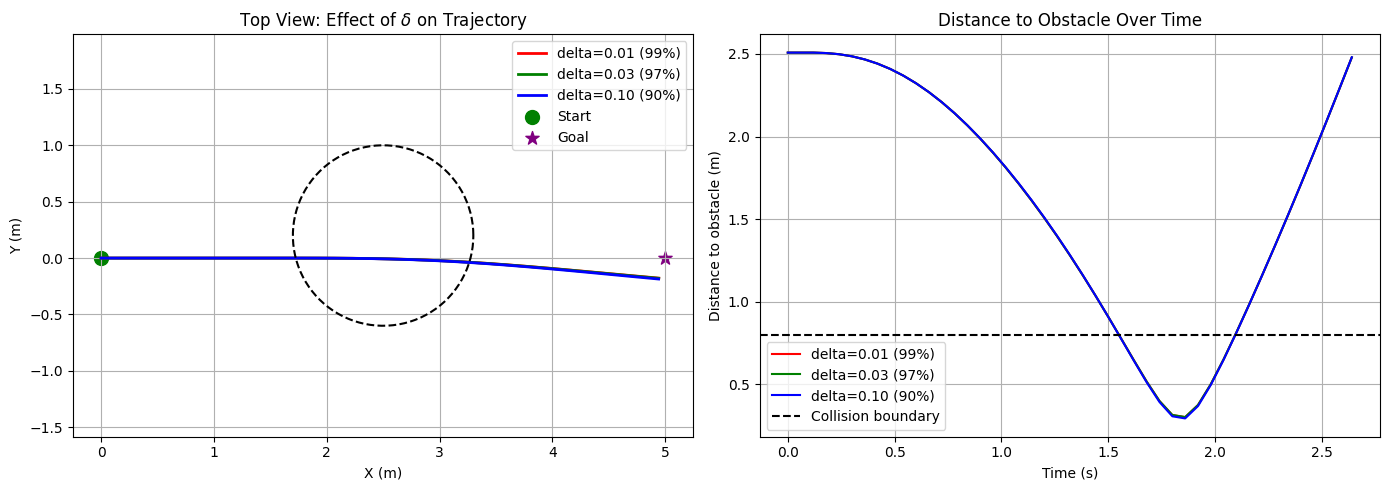

In [2]:
# Demo: effect of delta on obstacle avoidance
start = np.zeros(9)
start[2] = 1.5  # initial altitude
goal = np.array([5.0, 0.0, 1.5])
obs_pos = np.array([2.5, 0.2, 1.5])
obs_radius = 0.8

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

delta_values = [(0.01, 'red', 'delta=0.01 (99%)'), (0.03, 'green', 'delta=0.03 (97%)'), (0.10, 'blue', 'delta=0.10 (90%)')]

for d_val, color, label in delta_values:
    traj = fly_to_goal(start, goal, obs_pos, obs_radius, delta_cons=d_val)
    ax1.plot(traj[:, 0], traj[:, 1], color=color, label=label, linewidth=2)
    distances = [np.linalg.norm(p[:3] - obs_pos) for p in traj]
    ax2.plot(np.arange(len(distances)) * 0.06, distances, color=color, label=label)
    min_dist = min(distances)
    print(f'{label}: min distance = {min_dist:.3f}m, {len(traj)-1} steps')

# Plot obstacle
th = np.linspace(0, 2*np.pi, 100)
ax1.plot(obs_pos[0] + obs_radius*np.cos(th), obs_pos[1] + obs_radius*np.sin(th), 'k--', linewidth=1.5)
ax1.scatter(0, 0, c='g', s=100, marker='o', label='Start')
ax1.scatter(*goal[:2], c='purple', s=100, marker='*', label='Goal')
ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)')
ax1.set_title('Top View: Effect of $\\delta$ on Trajectory'); ax1.legend(); ax1.axis('equal'); ax1.grid(True)

ax2.axhline(obs_radius, color='k', linestyle='--', label='Collision boundary')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Distance to obstacle (m)')
ax2.set_title('Distance to Obstacle Over Time'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/4.0_ccmpc.png', dpi=100, bbox_inches='tight')
plt.show()


# Summary

- **CC-MPC** avoids obstacles with probabilistic guarantees
- **delta controls conservatism** — larger delta allows closer approach
- **Repulsive field** provides smooth avoidance behavior
- **Soft constraints** prevent QP infeasibility in practice

**Next**: [[4.2 Full CC-MPC Demo]]